# Illustrations for chapter 5 of lecture notes "Pricing and hedging of financial derivatives"

## Explicit scheme
Terminal condition: option's pay-off: $u(t_N,x_m) =
\tilde h(x_m)$, $\tilde h(x) = h(s_0 e^x)$.


Finite difference equation for $\hat u_{n,m}$:
\begin{align*}
&\hat u_{n-1,m} = \hat u_{n,m}\left\{1 - \frac{\tilde
  \sigma^2(t_n,x_m)\Delta t}{ \Delta x^2}\right\} + \hat u_{n,m+1}\frac{\tilde
  \sigma^2(t_n,x_m)\Delta t}{2 \Delta x^2}\left(1-\frac{\Delta
    x}{2}\right) \\ &\qquad +\hat u_{n,m-1}\frac{\tilde \sigma^2(t_n,x_m)\Delta t}{2 \Delta x^2}\left(1+\frac{\Delta x}{2}\right)\\
&\hat u_{n,0} = g(t_n,x_0),\  \hat u_{n,M} = g(t_n,x_M),\ \forall n;
  \quad \hat u_{N,m} = \tilde h(x_m),\ \forall m.
\end{align*}
Equation is
solved backwards from $n=N$ to
$n=0$.

## Implicit scheme
\begin{align*}
&\frac{\partial u(t_n,x_m)}{\partial t}\approx
\frac{u(t_{n+1},x_m)-u(t_{n},x_m)}{\Delta t},\quad 0\leq n \leq N-1\\
&\Rightarrow \quad \hat u_{n,m}= \hat u_{n-1,m} \left\{1+\frac{\tilde
  \sigma^2(t_{n-1},x_m)\Delta t}{ \Delta x^2}\right\} - \hat u_{{n-1},m+1}\frac{\tilde
  \sigma^2(t_{n-1},x_m)\Delta t}{2 \Delta x^2}\left(1-\frac{\Delta
    x}{2}\right) \\ &\qquad \qquad-
\hat u_{n-1,m-1}\frac{\tilde \sigma^2(t_{n-1},x_m)\Delta t}{2 \Delta x^2}\left(1+\frac{\Delta x}{2}\right).
\end{align*}

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

S0 = 100
sigmin = 0.1
sigmax = 0.4
def h(S,K):
    return (S-K)*(S>K)
def htil(x,K):
    return h(S0*np.exp(x),K)
def sigtil(x,sigmin,sigmax):
    return sigmin+(sigmax-sigmin)*(-np.arctan(3*x)+np.pi/2)/np.pi
def bsprice(S,K,T,r,v):
    d1 = (np.log(S/K)+(r+v*v/2.)*T)/(v*np.sqrt(T))
    d2 = d1-v*np.sqrt(T)
    return S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)

Text(0, 0.5, 'sigma')

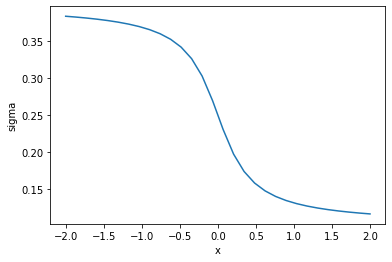

In [ ]:
x = np.linspace(-2,2,30)
plt.plot(x,sigtil(x,0.1,0.4))
plt.xlabel('x')
plt.ylabel('sigma')

In [ ]:
def explicit(T, g, htil, sigtil,  Ntime=100, Nspace=100,A = 2):
    x = np.linspace(-A,A,Nspace+1) # space grid
    t = np.linspace(0,T,Ntime+1) # time grid
    u = np.zeros((Ntime+1,Nspace+1)) # unknown function
    u[Ntime,:] = htil(x) # initialize with the pay-off
    dt = 1.*T/Ntime # time step
    dx = 2.*A/Nspace # spacec step
    p = sigtil(x[1:-1])**2*dt/2./dx**2*(1-dx/2.) # coefficients of the equation
    q = sigtil(x[1:-1])**2*dt/2./dx**2*(1+dx/2.)
    print(np.min(1.-p-q))
    for i in range(Ntime,0,-1): # main loop
        u[i-1,1:-1] = p*u[i,2:]+q*u[i,:-2] + (1.-p-q)*u[i,1:-1]
        u[i-1,0] = g(t[i-1],x[0]) # boundary conditions
        u[i-1,Nspace] = g(t[i-1],x[Nspace]) # boundary condition
    return x,u

def implicit(T, g, htil, sigtil,  Ntime=100, Nspace=100,A = 2):
    x = np.linspace(-A,A,Nspace+1) # space grid
    t = np.linspace(0,T,Ntime+1) # time grid
    u = np.zeros((Ntime+1,Nspace+1)) # unknown function
    u[Ntime,:] = htil(x) # initialization
    dt = 1.*T/Ntime # time step
    dx = 2.*A/Nspace # space step
    p = sigtil(x[1:-1])**2*dt/2./dx**2*(1-dx/2.) # coefficients
    q = sigtil(x[1:-1])**2*dt/2./dx**2*(1+dx/2.)
    Amat = np.zeros((Nspace-1,Nspace-1))
    for i in range(Nspace-2):
        Amat[i,i] = 1.+p[i]+q[i]
        Amat[i,i+1] = -p[i]
        Amat[i+1,i] = -q[i+1]
    Amat[-1,-1] = 1.+p[-1]+q[-1]
    Ainv = np.linalg.inv(Amat) # matrix inversion
    v = np.zeros(Nspace-1) # boundary conditions
    for i in range(Ntime,0,-1):
        v[0] = -q[0]*g(t[i-1],x[0])
        v[-1] = -p[-1]*g(t[i-1],x[Nspace])
        u[i-1,1:-1] = np.dot(Ainv,u[i,1:-1]-v) # main loop
        u[i-1,0] = g(t[i-1],x[0])
        u[i-1,Nspace] = g(t[i-1],x[Nspace])
    return x,u

## Convergence and stability of explicit scheme

0.4375
0.4375000000000001
0.96484375


Text(0.5, 1.0, 'Pricing error')

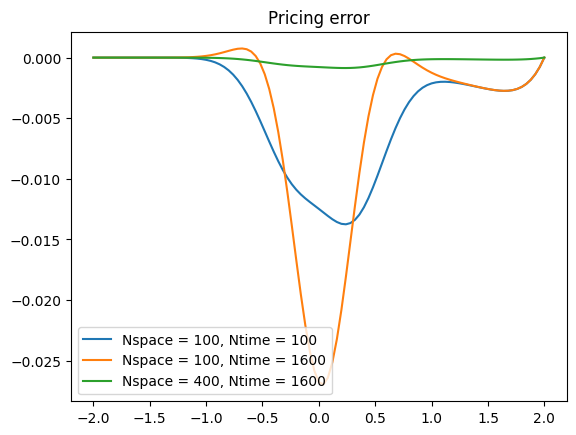

In [ ]:
K= 100
T = 1.0
sigmin = 0.3
sigmax = 0.3


x1,u1 = explicit(T, lambda t,x:htil(x,K), lambda x:htil(x,K),
                 lambda x:sigtil(x,sigmin,sigmax),Ntime=100,Nspace=100)
x2,u2 = explicit(T, lambda t,x:htil(x,K), lambda x:htil(x,K),
                 lambda x:sigtil(x,sigmin,sigmax),Ntime=1600,Nspace=400)
x3,u3 = explicit(T, lambda t,x:htil(x,K), lambda x:htil(x,K),
                 lambda x:sigtil(x,sigmin,sigmax),Ntime=1600,Nspace=100)
bs = bsprice(S0*np.exp(x1),K,T,0.,sigmax)# true solution

plt.plot(x1,u1[0,:]-bs,label='Nspace = 100, Ntime = 100')
plt.plot(x1,u3[0,:]-bs,label='Nspace = 100, Ntime = 1600')
plt.plot(x1,u2[0,::4]-bs,label='Nspace = 400, Ntime = 1600')
plt.legend()
plt.title('Pricing error')

## Comparison of explicit and implicit scheme

-0.5574034705043451


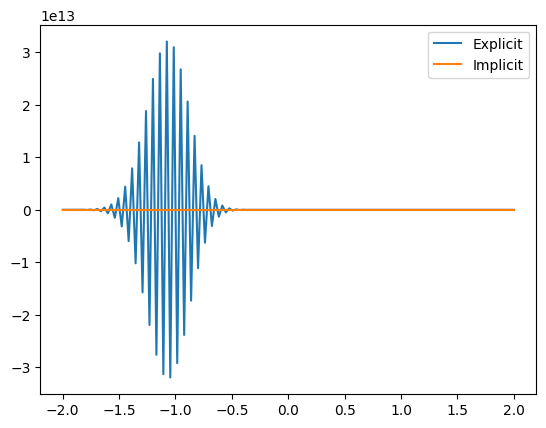

In [ ]:
K= 100
T = 1.0
sigmin = 0.1
sigmax = 0.4
x1,u1 = explicit(T, lambda t,x:htil(x,K), lambda x:htil(x,K),
                 lambda x:sigtil(x,sigmin,sigmax),Ntime=100,Nspace=130)
x2,u2 = implicit(T, lambda t,x:htil(x,K), lambda x:htil(x,K),
                 lambda x:sigtil(x,sigmin,sigmax),Ntime=100,Nspace=130)
plt.plot(x1,u1[0,:],label='Explicit')
plt.plot(x2,u2[0,:],label='Implicit')
plt.legend()


## Boundary conditions

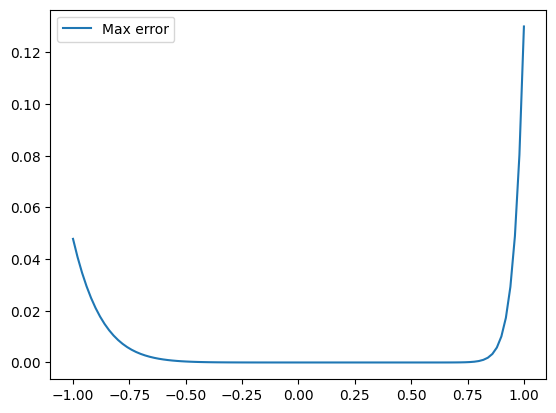

In [ ]:
K= 100
T = 1.0
sigmin = 0.1
sigmax = 0.4
x1,u1 = implicit(T, lambda t,x:bsprice(S0*np.exp(x),K,T-t,0.,sigmin), lambda x:htil(x,K),
                 lambda x:sigtil(x,sigmin,sigmax),Ntime=100,Nspace=100,A = 1.0)
x2,u2 = implicit(T, lambda t,x:bsprice(S0*np.exp(x),K,T-t,0.,sigmax), lambda x:htil(x,K),
                 lambda x:sigtil(x,sigmin,sigmax),Ntime=100,Nspace=100, A = 1.0)
plt.plot(x1,u2[0,:]-u1[0,:],label='Max error')
plt.legend()

## Control variates: Basket call in the Black-Scholes model

In [ ]:

def BasketCallPay(S0,alpha,K,T,r,sigma,R,N): # preparing the pay-offs and control variates
    d = len(S0)
    W = np.dot(np.linalg.cholesky(R),np.random.normal(size=(len(S0),N)))# Simulate correlated BM using Cholesky
    X = np.log(S0) + (r-sigma**2/2)*T
    X = np.dot(X.reshape((d,1)),np.ones((1,N))) # compute X_T (d dimensions times N samples)
    X = X + np.dot(np.diag(sigma),W)*np.sqrt(T) # add stochastic component
    payoff = np.dot(alpha,np.exp(X))-K # basket option pay-off
    payoff = np.exp(-r*T)*payoff*(payoff>0) # discounting + positive part
    payoff_min = np.exp(X)-K # lower control variate
    payoff_min = np.exp(-r*T)*np.dot(alpha,payoff_min*(payoff_min>0))
    payoff_max = np.exp(np.dot(alpha,X))-K # upper control variate
    payoff_max = np.exp(-r*T)*payoff_max*(payoff_max>0)

    price_min = np.dot(alpha,bsprice(S0,K,T,r,sigma)) # expectation of lower control variate by Black-Scholes
    sig2til = np.dot(np.dot(R,alpha*sigma),alpha*sigma)
    Stil = np.exp(np.dot(alpha,np.log(S0))+T/2*(sig2til-np.sum(alpha*sigma*sigma)))
    price_max = bsprice(Stil,K,T,r,np.sqrt(sig2til)) # expectation of upper control variate by Black-Scholes
    return payoff,payoff_min,payoff_max,price_min,price_max

def BasketCall(S0,alpha,K,T,r,sigma,R,N): # Computation of the estimator
    pay, paymin, paymax, cmin, cmax = BasketCallPay(S0,alpha,K,T,r,sigma,R,N)
    pmin = np.mean(paymin)
    smin = np.std(paymin)/np.sqrt(N)
    pmax = np.mean(paymax)
    smax = np.std(paymax)/np.sqrt(N)
    Covmat = np.cov([pay,paymin,paymax]) # 3 by 3 matrix because two control variates + payoff
    SXX = Covmat[1:,1:] # 2 by 2 covariance matrix of control variates
    SXY = Covmat[0,1:] # covariance of Y with control variates
    bstar = - np.dot(np.linalg.inv(SXX),SXY) # optimal b
    print('b*=',bstar)
    pcor = pay + bstar[0]*(paymin-cmin) + bstar[1]*(paymax-cmax) # control variate estimator
    p = np.mean(pcor)
    s = np.std(pcor)/np.sqrt(N)
    pp = np.mean(pay)
    ps = np.std(pay)/np.sqrt(N)
    return p,s,pp,ps,pmin, smin, cmin, pmax, smax, cmax


In [ ]:
S0 = 100*np.ones(3)
alpha = np.ones(3)/3.
K = 100
T = 0.5
r = 0.02
sigma = np.array([0.3, 0.3, 0.2]) # volatilities of stocks
R = np.array([[1., 0.3, 0.3], [0.3, 1., 0.3],[0.3, 0.3, 1.]]) # correlation of stocks
N = 250000 # sample size
p,s,pp,ps,pmin, smin, cmin, pmax, smax, cmax = BasketCall(S0,alpha,K,T,r,sigma,R,N)
print(f"{N} & {K} & {p:5.3} & {s:5.3} & {pp:5.3} & {ps:5.3} & {ps/s:5.3}")
# p: control variate estimator
# s: standard deviation
# pp: standard estimator without control varites
# ps: standard deviation without control variates
# ps/s standard deviation reduction ratio

K = 120
p,s,pp,ps,pmin, smin, cmin, pmax, smax, cmax = BasketCall(S0,alpha,K,T,r,sigma,R,N)
print(f"{N} & {K} & {p:5.3} & {s:5.3} & {pp:5.3} & {ps:5.3} & {ps/s:5.3}")

K = 80
p,s,pp,ps,pmin, smin, cmin, pmax, smax, cmax = BasketCall(S0,alpha,K,T,r,sigma,R,N)
print(f"{N} & {K} & {p:5.3} & {s:5.3} & {pp:5.3} & {ps:5.3} & {ps/s:5.3}")





b*= [-0.18787582 -0.86261873]
250000 & 100 &  6.02 & 0.00108 &   6.0 & 0.0183 &  16.9
b*= [-0.09238557 -0.98505433]
250000 & 120 & 0.793 & 0.000723 & 0.797 & 0.00677 &  9.37
b*= [-0.37061634 -0.6609018 ]
250000 & 80 &  21.0 & 0.00114 &  21.0 & 0.0271 &  23.8


## Importance sampling

In [ ]:
def digital(S0,K,T,sigma,N):
    W = np.random.normal(size=N)*np.sqrt(T)
    S = S0*np.exp(sigma*W-sigma**2*T/2)
    p = np.mean(1.*(S<K))
    ps = np.std(1.*(S<K))/np.sqrt(N)
    d = (np.log(K/S0)+sigma**2*T/2)/sigma/np.sqrt(T)
    lam = -d/np.sqrt(T)# optimal variance reduction parameter
    pay = np.exp(lam*W - lam**2*T/2)*(S0*np.exp(-sigma**2*T/2+ sigma*(W-lam*T))<K)
    pis = np.mean(pay)
    piss = np.std(pay)/np.sqrt(N)
    return p, ps, pis, piss

In [ ]:
S0, K, T, sigma, N = 100, 50, 0.5, 0.3, 10000
p, ps, pis, piss = digital(S0, 90, T, sigma, N)
print(f"{N} & {K} & {p:5.3} & {ps:5.3} & {ps/p:5.3} & {pis:5.3} & {piss:5.3} & {piss/pis:5.3}")

p, ps, pis, piss = digital(S0, 80, T, sigma, N)
print(f"{N} & {K} & {p:5.3} & {ps:5.3} & {ps/p:5.3} & {pis:5.3} & {piss:5.3} & {piss/pis:5.3}")

p, ps, pis, piss = digital(S0, 70, T, sigma, N)
print(f"{N} & {K} & {p:5.3} & {ps:5.3} & {ps/p:5.3} & {pis:5.3} & {piss:5.3} & {piss/pis:5.3}")

p, ps, pis, piss = digital(S0, 60, T, sigma, N)
print(f"{N} & {K} & {p:5.3} & {ps:5.3} & {ps/p:5.3} & {pis:5.3} & {piss:5.3} & {piss/pis:5.3}")

p, ps, pis, piss = digital(S0, 50, T, sigma, N)
print(f"{N} & {K} & {p:5.3} & {ps:5.3} & {ps/p:5.3} & {pis:5.3} & {piss:5.3} & {piss/pis:5.3}")

10000 & 50 & 0.342 & 0.00475 & 0.0139 & 0.342 & 0.00363 & 0.0106
10000 & 50 & 0.176 & 0.00381 & 0.0217 &  0.17 & 0.00204 & 0.012
10000 & 50 & 0.0578 & 0.00233 & 0.0404 & 0.0582 & 0.0008 & 0.0138
10000 & 50 & 0.0104 & 0.00101 & 0.0975 & 0.0108 & 0.000175 & 0.0162
10000 & 50 & 0.0011 & 0.000331 & 0.301 & 0.000763 & 1.46e-05 & 0.0191


## Euler scheme

We use the Euler scheme to solve the equation
$$
\frac{dS_t}{S_t} = r dt + \sigma(S_t) dW_t,\quad \sigma(S) = \sigma_{min}+(\sigma_{max}-\sigma_{min})(-\arctan(3\log S)+\pi/2)/\pi
$$

In [ ]:
def euler(sig,r,S0,T,Ldisc,Nsim):
  # Simulate Euler scheme trajectories with step sizes T/2^k for k between 0 and Ldisc
    Ndisc = 1<<Ldisc
    dt = T/Ndisc
    inc = np.zeros((Ldisc+1,Nsim))
    S = S0*np.ones((Ldisc+1,Nsim))
    W = np.zeros(Nsim)
    for i in range(Ndisc):
        dW = np.random.normal(size=Nsim)*np.sqrt(dt)
        W = W+dW
        for j in range(Ldisc+1):
            inc[j,:] = inc[j,:]+dW
            if((i+1)%(1<<j)==0):
                S[j,:] = S[j,:]*(1+r*dt*(1<<j)+sig(S[j,:])*inc[j,:])# Main step of the Euler scheme
                inc[j,:] = 0
    return S,W



In [ ]:
# Comparison with Black-Scholes
def sigma(S,sigmin,sigmax):
    return sigmin+(sigmax-sigmin)*(-np.arctan(3*np.log(S))+np.pi/2)/np.pi
r = 0.05
S0 = 100
T = 0.5
Ldisc = 10
Nsim = 1000000
sigmin = 0.3
sigmax = 0.3
S,W = euler(lambda S:sigma(S,sigmin,sigmax),r,S0,T,Ldisc,Nsim) # Euler scheme - not Black-Scholes
Se = S0*np.exp((r-sigmin**2/2)*T+sigmin*W)
Se = np.dot(np.ones((Ldisc+1,1)),Se.reshape((1,Nsim)))
L2err = np.mean((S-Se)**2,axis=1) # E[(S^n-S)^2]
xval = (Ldisc-np.arange(Ldisc+1))*np.log(2.)

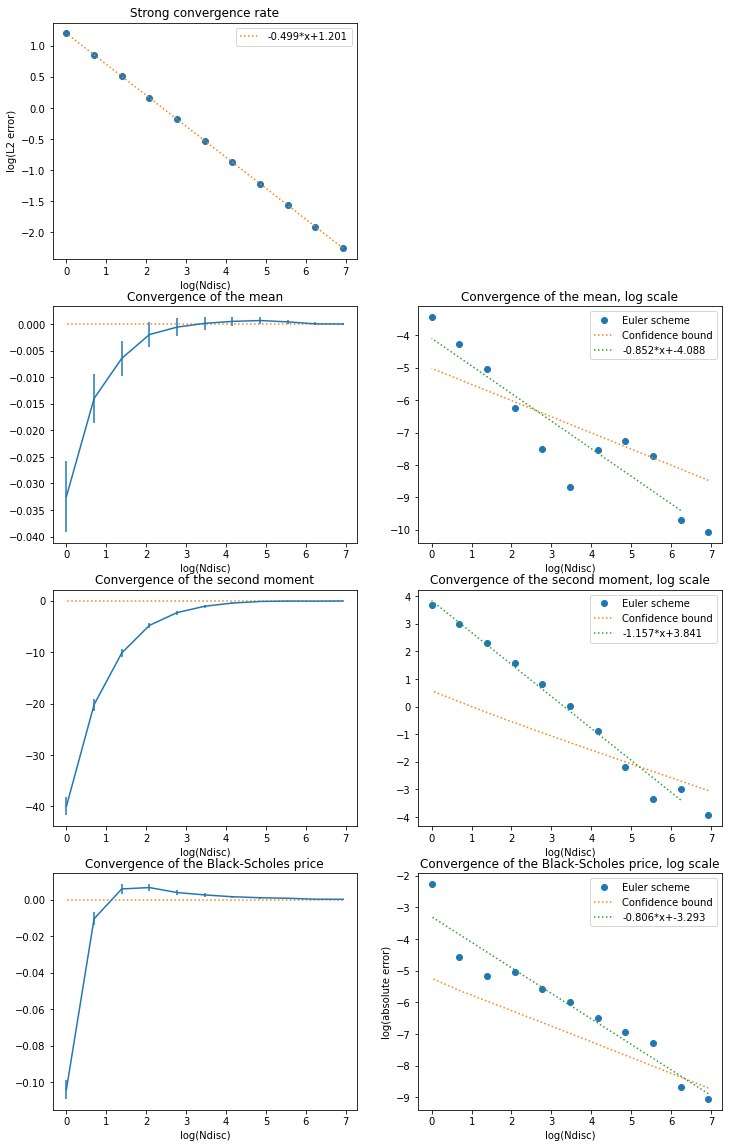

In [ ]:

plt.figure(figsize=(12,20))
plt.subplot(421)
plt.plot(xval,0.5*np.log(L2err),'o')
plt.xlabel('log(Ndisc)')
plt.ylabel('log(L2 error)')
plt.title('Strong convergence rate')
coefs = np.polyfit(xval,0.5*np.log(L2err),1)
lab = '{:.3f}*x+{:.3f}'.format(coefs[0],coefs[1])
plt.plot(xval,xval*coefs[0]+coefs[1],':',label=lab)
plt.legend()

plt.subplot(423)
plt.title('Convergence of the mean')
plt.xlabel('log(Ndisc)')
deltaS = S-Se
plt.errorbar(xval,np.mean(deltaS,axis=1),2.*np.std(deltaS,axis=1)/np.sqrt(Nsim))
plt.plot(xval,np.zeros(len(xval)),':')

plt.subplot(424)
plt.title('Convergence of the mean, log scale')
plt.xlabel('log(Ndisc)')
plt.plot(xval,np.log(np.abs(np.mean(deltaS,axis=1))),'o',label='Euler scheme')
plt.plot(xval,np.log(2.*np.std(deltaS,axis=1)/np.sqrt(Nsim)),':',label='Confidence bound')
coefs = np.polyfit(xval,np.log(np.fabs(np.mean(deltaS,axis=1))),1)
lab = '{:.3f}*x+{:.3f}'.format(coefs[0],coefs[1])
plt.plot(xval[1:],xval[1:]*coefs[0]+coefs[1],':',label=lab)
plt.legend()

plt.subplot(425)
plt.title('Convergence of the second moment')
plt.xlabel('log(Ndisc)')
deltaS2 = S*S - Se*Se
plt.errorbar(xval,np.mean(deltaS2,axis=1),2.*np.std(deltaS2,axis=1)/np.sqrt(Nsim))
plt.plot(xval,np.zeros(len(xval)),':')

plt.subplot(426)
plt.title('Convergence of the second moment, log scale')
plt.xlabel('log(Ndisc)')
plt.plot(xval,np.log(np.abs(np.mean(deltaS2,axis=1))),'o',label='Euler scheme')
coefs = np.polyfit(xval,np.log(np.fabs(np.mean(deltaS2,axis=1))),1)
plt.plot(xval,np.log(2.*np.std(deltaS2,axis=1)/np.sqrt(Nsim)),':',label='Confidence bound')
lab = '{:.3f}*x+{:.3f}'.format(coefs[0],coefs[1])
plt.plot(xval[1:],xval[1:]*coefs[0]+coefs[1],':',label=lab)
plt.legend()

K = 100
deltaPay = (S-K)*(S>K)*np.exp(-r*T) - (Se-K)*(Se>K)*np.exp(-r*T)
plt.subplot(427)
plt.title('Convergence of the Black-Scholes price')
plt.xlabel('log(Ndisc)')
plt.errorbar(xval,np.mean(deltaPay,axis=1),2.*np.std(deltaPay,axis=1)/np.sqrt(Nsim))
plt.plot(xval,np.zeros(len(xval)),':')

plt.subplot(428)
plt.plot(xval,np.log(np.abs(np.mean(deltaPay,axis=1))),'o',label='Euler scheme')
plt.plot(xval,np.log(2.*np.std(deltaPay,axis=1)/np.sqrt(Nsim)),':',label='Confidence bound')
coefs = np.polyfit(xval,np.log(np.abs(np.mean(deltaPay,axis=1))),1)
lab = '{:.3f}*x+{:.3f}'.format(coefs[0],coefs[1])
plt.plot(xval,xval*coefs[0]+coefs[1],':',label=lab)
plt.xlabel('log(Ndisc)')
plt.ylabel('log(absolute error)')
plt.title('Convergence of the Black-Scholes price, log scale')

plt.legend()






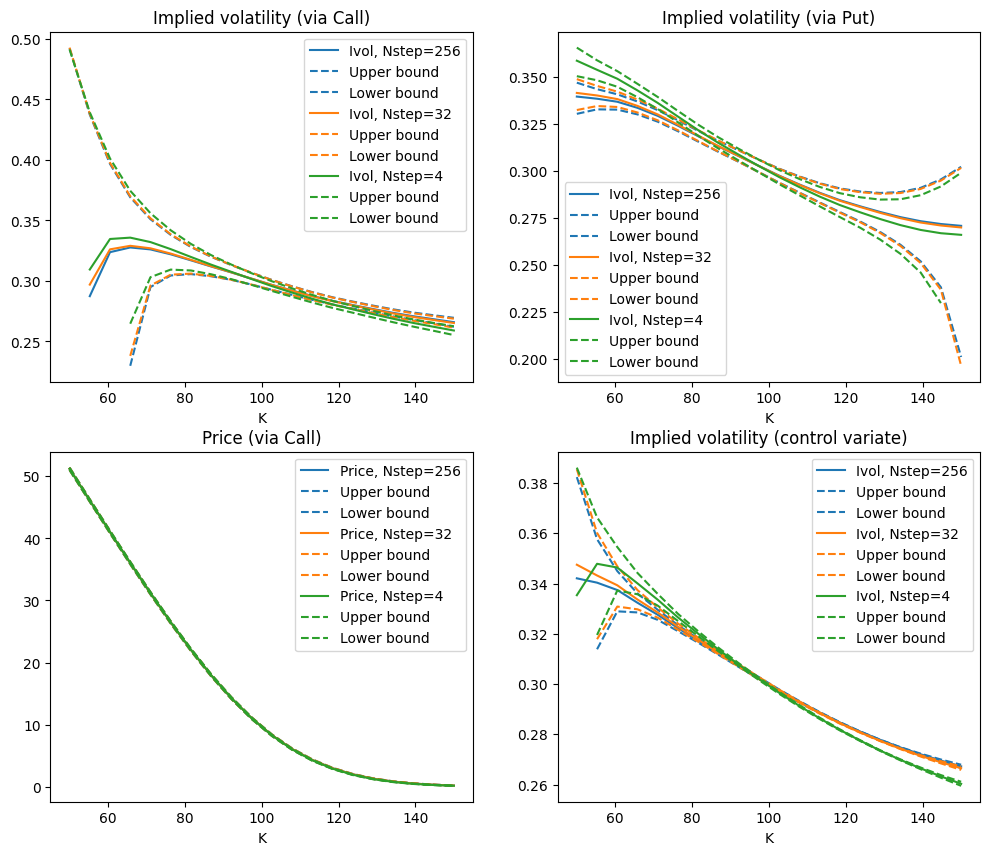

In [ ]:
# Computing implied volatility in a local vol model by Monte Carlo

def volimp(s,k,t,r,c):
    if((c <= max(s-k*np.exp(-r*t), 0)) or (c>=s)) :
        return float('nan')
    a=0.
    b = 1.
    fb = bsprice(s, k, t, r, b)
    for i in range(10):
        if(c<=fb):
            break
        a= b
        b=b*2.0
        fb = bsprice(s,k,t,r,b)
    if(i >= 10):
        return float('nan')
    for j in range(30+i):
        fb = bsprice(s,k,t,r,(a+b)/2.)
        if(fb > c) :
            b = (a+b)/2.
        else:
            a= (a+b)/2.
    return  (a+b)/2.

def sigma(S,sigmin,sigmax,S0):
    return sigmin+(sigmax-sigmin)*(-np.arctan(3*np.log(S/S0))+np.pi/2)/np.pi
r = 0.05
S0 = 100
T = 0.5
Ldisc = 8 # Discretization step sizes range from T (single step) to T/2^Ldisc
Nsim = 50000 # Number of simulations
sigmin = 0.2
sigmax = 0.4
S,W = euler(lambda S:sigma(S,sigmin,sigmax,S0),r,S0,T,Ldisc,Nsim) # Simulate trajectories by Euler scheme
Scv = S0*np.exp((r-sigma(S0,sigmin,sigmax,S0)**2/2)*T+sigma(S0,sigmin,sigmax,S0)*W) # Compute stock price value for control variate
Scv = np.dot(np.ones((Ldisc+1,1)),Scv.reshape((1,Nsim))) # Use same control variate for all discretization steps
K = np.linspace(50,150,20)
price_mean = np.zeros((Ldisc+1,len(K)))
price_std = np.zeros((Ldisc+1,len(K)))
price_ivol = np.zeros((Ldisc+1,len(K)))
price_ivol_up = np.zeros((Ldisc+1,len(K)))
price_ivol_down = np.zeros((Ldisc+1,len(K)))
pprice_mean = np.zeros((Ldisc+1,len(K)))
pprice_std = np.zeros((Ldisc+1,len(K)))
pprice_ivol = np.zeros((Ldisc+1,len(K)))
pprice_ivol_up = np.zeros((Ldisc+1,len(K)))
pprice_ivol_down = np.zeros((Ldisc+1,len(K)))
cvprice_mean = np.zeros((Ldisc+1,len(K)))
cvprice_ivol = np.zeros((Ldisc+1,len(K)))
cvprice_std = np.zeros((Ldisc+1,len(K)))
cvprice_ivol_up = np.zeros((Ldisc+1,len(K)))
cvprice_ivol_down = np.zeros((Ldisc+1,len(K)))

for i in range(len(K)):
  pay = (S-K[i])*(S>K[i])*np.exp(-r*T) # Compute pay-off of call option
  pay_cv = (Scv-K[i])*(Scv>K[i])*np.exp(-r*T) # control variate
  ppay = (K[i]-S)*(K[i]>S)*np.exp(-r*T) # Compute pay-off of put option
  price_mean[:,i] = np.mean(pay,axis=1) # Compute empirical mean of call pay-off
  price_std[:,i] = np.std(pay,axis=1)/np.sqrt(Nsim) # Compute standard deviation of call pay-off
  pprice_mean[:,i] = np.mean(ppay,axis=1)+S0-K[i]*np.exp(-r*T) # Compute empirical mean of put pay-off
  pprice_std[:,i] = np.std(ppay,axis=1)/np.sqrt(Nsim) # Compute standard deviation of put pay-off
  for j in range(Ldisc+1):
    Covmat = np.cov([pay[j,:],pay_cv[j,:]]) # Compute covariance matrix of pay-off and control variate
    SXX = Covmat[1,1] #
    SXY = Covmat[0,1]
    bstar = - SXY/SXX # Optimal coefficient
    pay_cor = pay[j,:] + bstar*(pay_cv[j,:]-bsprice(S0,K[i],T,r,sigma(S0,sigmin,sigmax,S0))) # Compute corrected pay-off
    cvprice_mean[j,i] = np.mean(pay_cor) # Empirical mean of corrected pay-off
    cvprice_std[j,i] = np.std(pay_cor)/np.sqrt(Nsim) # Standard deviation of corrected pay-off

  for j in range(Ldisc+1):
    price_ivol[j,i] = volimp(S0,K[i],T,r,price_mean[j,i]) # Implied volatility via call
    price_ivol_up[j,i] = volimp(S0,K[i],T,r,price_mean[j,i]+2*price_std[j,i]) # Implied volatility upper bound
    price_ivol_down[j,i] = volimp(S0,K[i],T,r,price_mean[j,i]-2*price_std[j,i]) # Implied volatility lower bound
    pprice_ivol[j,i] = volimp(S0,K[i],T,r,pprice_mean[j,i]) # Implied volatility via put
    pprice_ivol_up[j,i] = volimp(S0,K[i],T,r,pprice_mean[j,i]+2*pprice_std[j,i]) # Implied volatility upper bound
    pprice_ivol_down[j,i] = volimp(S0,K[i],T,r,pprice_mean[j,i]-2*pprice_std[j,i]) # Implied volatility lower bound
    cvprice_ivol[j,i] = volimp(S0,K[i],T,r,cvprice_mean[j,i]) # Implied volatility via control variate
    cvprice_ivol_up[j,i] = volimp(S0,K[i],T,r,cvprice_mean[j,i]+2*cvprice_std[j,i]) # Implied volatility upper bound
    cvprice_ivol_down[j,i] = volimp(S0,K[i],T,r,cvprice_mean[j,i]-2*cvprice_std[j,i]) # Implied volatility lower bound


plt.figure(figsize=(12,10))
plt.subplot(221)
plt.title('Implied volatility (via Call)')
plt.xlabel('K')
for i in range(0,Ldisc+1,3):
  line, = plt.plot(K,price_ivol[i,:],label='Ivol, Nstep='+str(np.power(2,Ldisc-i)))
  plt.plot(K,price_ivol_up[i,:],'--',label='Upper bound',color=line.get_color())
  plt.plot(K,price_ivol_down[i,:],'--',label='Lower bound',color=line.get_color())
plt.legend()
plt.subplot(222)
plt.title('Implied volatility (via Put)')
plt.xlabel('K')
for i in range(0,Ldisc+1,3):
  line, = plt.plot(K,pprice_ivol[i,:],label='Ivol, Nstep='+str(np.power(2,Ldisc-i)))
  plt.plot(K,pprice_ivol_up[i,:],'--',label='Upper bound',color=line.get_color())
  plt.plot(K,pprice_ivol_down[i,:],'--',label='Lower bound',color=line.get_color())
plt.legend()
plt.subplot(223)
plt.title('Price (via Call)')
plt.xlabel('K')
for i in range(0,Ldisc+1,3):
  line, = plt.plot(K,price_mean[i,:],label='Price, Nstep='+str(np.power(2,Ldisc-i)))
  plt.plot(K,price_mean[i,:]+2*price_std[i,:],'--',label='Upper bound',color=line.get_color())
  plt.plot(K,price_mean[i,:]-2*price_std[i,:],'--',label='Lower bound',color=line.get_color())
plt.legend()
plt.subplot(224)
plt.title('Implied volatility (control variate)')
plt.xlabel('K')
for i in range(0,Ldisc+1,3):
  line, = plt.plot(K,cvprice_ivol[i,:],label='Ivol, Nstep='+str(np.power(2,Ldisc-i)))
  plt.plot(K,cvprice_ivol_up[i,:],'--',label='Upper bound',color=line.get_color())
  plt.plot(K,cvprice_ivol_down[i,:],'--',label='Lower bound',color=line.get_color())
plt.legend()



In [ ]:
from scipy.stats import kurtosis, skew
print(np.mean(S[0,:]),np.std(S[0,:]),skew(S[0,:]),kurtosis(S[0,:]))
print(sigma(S0,sigmin,sigmax,S0)*np.sqrt(T))

102.67717439308369 17.70052524675872 -0.0066025271283201 -0.08078372278326684
0.1767766952966369
